In [1]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
#pip install pandas

In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv


In [5]:
data = pd.read_csv('train.csv')

In [6]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
y = 1 - data["Survived"]
X = data[["Survived"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2023, test_size=0.25)

In [40]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train);

In [41]:
log_reg = LogisticRegression()

In [42]:
log_reg.fit(X_train, y_train);

Из-за возможного дисбаланса в датасете лучше использовать метрики Precision, Recall и F-меру».

**Precision & Recall**

In [43]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [44]:
confusion_matrix(y_test, y_pred_dummy)

array([[  0,  85],
       [  0, 138]])

In [45]:
confusion_matrix(y_test, y_pred_log_reg)

array([[ 85,   0],
       [  0, 138]])

In [46]:
print(f'Precision for Dummy Classificator: {precision_score(y_test, y_pred_dummy, zero_division=0)}')
print(f'Precision for Logistic regression: {precision_score(y_test, y_pred_log_reg, zero_division=0)}')

Precision for Dummy Classificator: 0.6188340807174888
Precision for Logistic regression: 1.0


In [47]:
print(f'Recall for Dummy Classificator: {recall_score(y_test, y_pred_dummy)}')
print(f'Recall for Logistic regression: {recall_score(y_test, y_pred_log_reg)}')

Recall for Dummy Classificator: 1.0
Recall for Logistic regression: 1.0


**F-мера**

In [48]:
from sklearn.metrics import f1_score, fbeta_score

In [49]:
print(f'F1-score for Dummy Classificator: {f1_score(y_test, y_pred_dummy)}')
print(f'F1-score for Logistic regression: {f1_score(y_test, y_pred_log_reg)}')

F1-score for Dummy Classificator: 0.7645429362880887
F1-score for Logistic regression: 1.0


In [50]:
print(f'Fbeta-score for Dummy Classificator (recall bias): {fbeta_score(y_test, y_pred_dummy, beta=2)}')
print(f'Fbeta-score for Logistic regression (recall bias): {fbeta_score(y_test, y_pred_log_reg, beta=2)}')

Fbeta-score for Dummy Classificator (recall bias): 0.8903225806451613
Fbeta-score for Logistic regression (recall bias): 1.0


In [51]:
print(f'Fbeta-score for Dummy Classificator (precision bias): {fbeta_score(y_test, y_pred_dummy, beta=0.5)}')
print(f'Fbeta-score for Logistic regression (precision bias): {fbeta_score(y_test, y_pred_log_reg, beta=0.5)}')

Fbeta-score for Dummy Classificator (precision bias): 0.6699029126213593
Fbeta-score for Logistic regression (precision bias): 1.0


In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

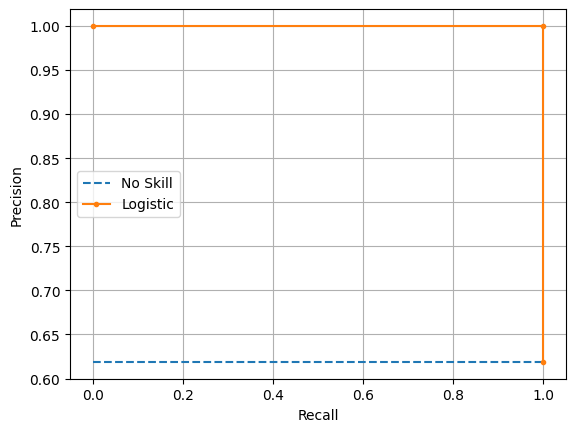

In [53]:
y_pred = log_reg.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
no_skill = len(y_test[y_test == 1]) / len(y_test)
plt.plot([0,1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()